### **Use Image**

In [1]:
!pip install Pillow


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Bài 1 - Biểu diễn dữ liệu thành ma trận & độ tương đồng

### 1.1 - Biến dữ liệu thành ma trận

In [2]:
import numpy as np
from PIL import Image
from pathlib import Path

IMAGE_DIR = Path("images")
H, W = 384, 384
N = 8
images_list = []

for i in range (1, N+1):
    path = IMAGE_DIR / (f"{i}.jpg")
    img = np.array(Image.open(path).convert ("L").resize((W, H)), dtype=float)
    img_flatten = img.flatten()
    images_list.append(img_flatten)

X = np.array(images_list)
print(f"X.shape = {X.shape}")

X.shape = (8, 147456)


### 1.2 - Phép toán cơ bản

In [3]:
X_mean = np.mean(X, axis=0, keepdims=True)
print(f"Kích thước ma trận dữ liệu X ban đầu:   {X.shape}")
print(f"Kích thước vector trung bình X_mean:    {X_mean.shape}")

X_new = X - X_mean

print(f"Kích thước ma trận mới sau khi trừ X: {X_new.shape}")

Kích thước ma trận dữ liệu X ban đầu:   (8, 147456)
Kích thước vector trung bình X_mean:    (1, 147456)
Kích thước ma trận mới sau khi trừ X: (8, 147456)


### 1.3 - Cosine similarity 

In [9]:
def cosine_similarity (X, Y=None) :
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg. norm(Y, axis=1, keepdims=True) 
    return Xn @ Yn. T   # ma tran tuong dong

similarity_matrix = cosine_similarity(X_new)
print("Ma trận tương đồng: \n", np.round(similarity_matrix, 3))

Ma trận tương đồng: 
 [[ 1.    -0.055  0.046 -0.253 -0.093 -0.216 -0.311 -0.049]
 [-0.055  1.     0.134 -0.205 -0.379 -0.15   0.043 -0.186]
 [ 0.046  0.134  1.    -0.24  -0.052  0.004 -0.211 -0.215]
 [-0.253 -0.205 -0.24   1.     0.009 -0.264 -0.049 -0.045]
 [-0.093 -0.379 -0.052  0.009  1.     0.129 -0.388 -0.094]
 [-0.216 -0.15   0.004 -0.264  0.129  1.    -0.195 -0.305]
 [-0.311  0.043 -0.211 -0.049 -0.388 -0.195  1.    -0.242]
 [-0.049 -0.186 -0.215 -0.045 -0.094 -0.305 -0.242  1.   ]]


### 1.4 - Truy vấn top k

In [13]:
def search(query, X, top_k=3):
    if len(query.shape) == 1:
        query = query.reshape(1, -1)

    scores_matrix = cosine_similarity(query, X)
    scores = scores_matrix[0]
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = [(idx + 1, scores[idx]) for idx in top_indices]
    return results

query_image = X[0]
top_k_results = search(query_image, X, top_k=8)
for rank, (id, score) in enumerate(top_k_results):
    print(f"Top {rank + 1}: Ảnh số {id} | Điểm Cosine = {score:.4f}")

Top 1: Ảnh số 1 | Điểm Cosine = 1.0000
Top 2: Ảnh số 3 | Điểm Cosine = 0.9388
Top 3: Ảnh số 2 | Điểm Cosine = 0.9216
Top 4: Ảnh số 5 | Điểm Cosine = 0.9087
Top 5: Ảnh số 4 | Điểm Cosine = 0.8953
Top 6: Ảnh số 8 | Điểm Cosine = 0.8951
Top 7: Ảnh số 6 | Điểm Cosine = 0.8895
Top 8: Ảnh số 7 | Điểm Cosine = 0.8361


### 1.5 - Nhận xét

- Ảnh giống ảnh query nhất (không xét chính nó) là ảnh 3
- Ảnh khác ảnh query nhất là ảnh 7
- Kết quả hoàn toàn khớp trực giác nhưng vẫn có 1 số ảnh bị sai lệch do hiện tại đang xử lí ảnh dạng thô trên pixel space

## Bài 2 - Biến đổi tuyến tính & SVD

### 2.1 - Biến đổi tuyến tính

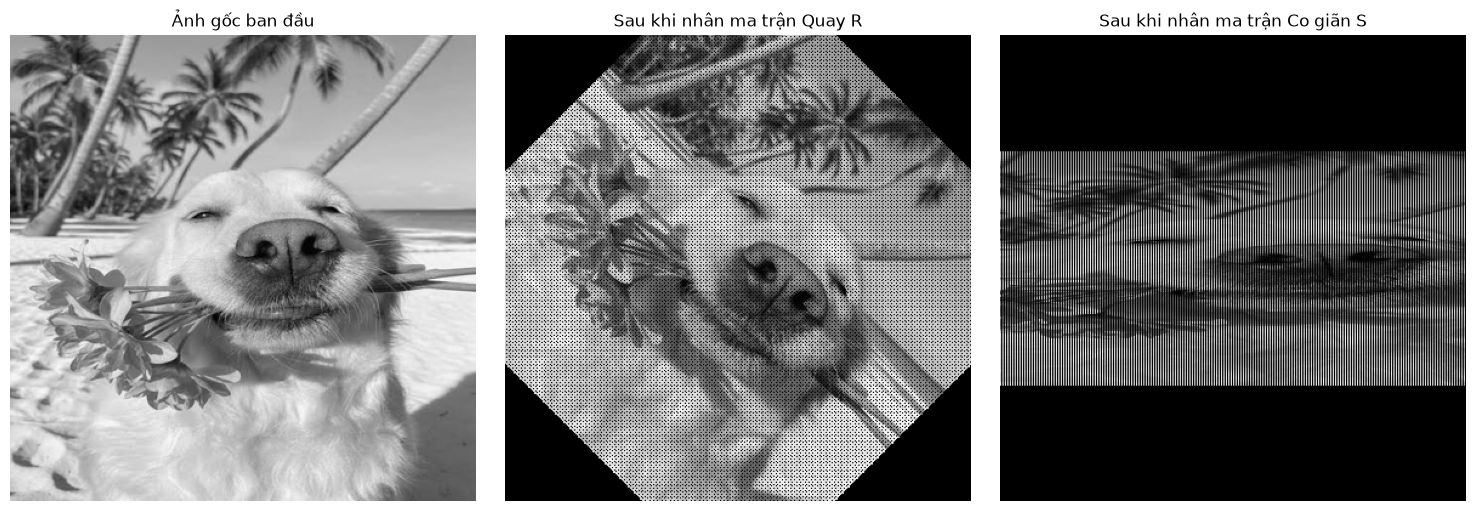

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

H, W = 384, 384
IMAGE_PATH = Path("images/1.jpg")
img_raw = np.array(Image.open(IMAGE_PATH).convert("L").resize((H, W)), dtype=float)

y_indices, x_indices = np.indices((H, W))
pixel_positions = np.vstack([x_indices.flatten(), y_indices.flatten()])

cx, cy = W // 2, H // 2
centered = pixel_positions - np.array([[cx], [cy]])

theta = np.radians(45)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

rotated = (R @ centered) + np.array([[cx], [cy]])

S = np.array([
    [sx,  0],
    [ 0, sy]
])

scaled = (S @ centered) + np.array([[cx], [cy]])

rotated_img = np.zeros_like(img_raw)
scaled_img = np.zeros_like(img_raw)

# Khôi phục lại màu xám từ ảnh raw numpy
for i in range(H * W):
    orig_x, orig_y = pixel_positions[0, i], pixel_positions[1, i]
    pixel_value = img_raw[orig_y, orig_x]
    
    rx, ry = int(round(rotated[0, i])), int(round(rotated[1, i]))
    if 0 <= rx < W and 0 <= ry < H:
        rotated_img[ry, rx] = pixel_value
        
    sx_c, sy_c = int(round(scaled[0, i])), int(round(scaled[1, i]))
    if 0 <= sx_c < W and 0 <= sy_c < H:
        scaled_img[sy_c, sx_c] = pixel_value

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_raw, cmap='gray')
plt.title("Ảnh gốc ban đầu")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rotated_img, cmap='gray')
plt.title("Sau khi nhân ma trận quay R")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(scaled_img, cmap='gray')
plt.title("Sau khi nhân ma trận co giãn S")
plt.axis('off')

plt.tight_layout()
plt.show()

### 2.2 - Nén ảnh bằng SVD

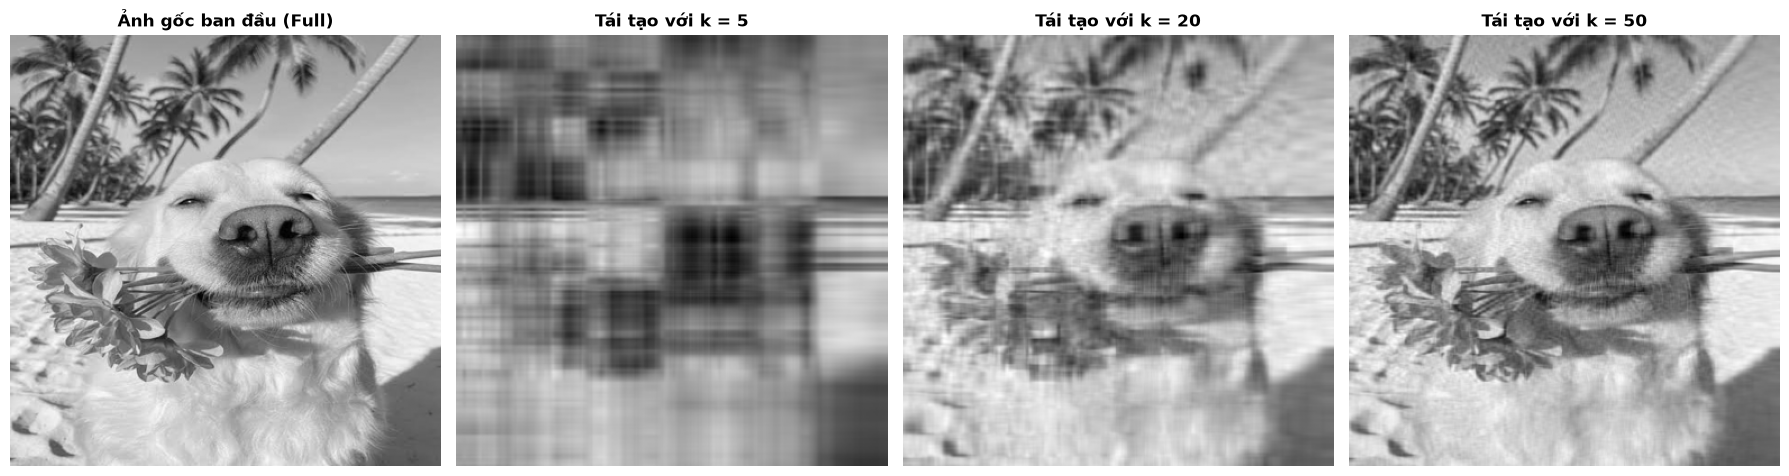

In [9]:
U, S, Vt = np.linalg.svd(img_raw, full_matrices=False)

def reconstruct (k) :
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k_list = [5, 20, 50]

plt.figure(figsize=(18, 5))
    
plt.subplot(1, 4, 1)
plt.imshow(img_raw, cmap='gray')
plt.title("Ảnh gốc ban đầu (Full)", fontsize=12, fontweight='bold')
plt.axis('off')

for index, k in enumerate(k_list):
    img_reconstructed = reconstruct(k)
    
    plt.subplot(1, 4, index + 2)
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title(f"Tái tạo với k = {k}", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2.3 - Đánh giá


Mức k = 5:
  -> Sai số tái tạo: 10456.45
  -> Tỉ lệ nén: 38.35x (Tiết kiệm dữ liệu ~ 2.6%)

Mức k = 20:
  -> Sai số tái tạo: 5468.86
  -> Tỉ lệ nén: 9.59x (Tiết kiệm dữ liệu ~ 10.4%)

Mức k = 50:
  -> Sai số tái tạo: 2776.90
  -> Tỉ lệ nén: 3.84x (Tiết kiệm dữ liệu ~ 26.1%)



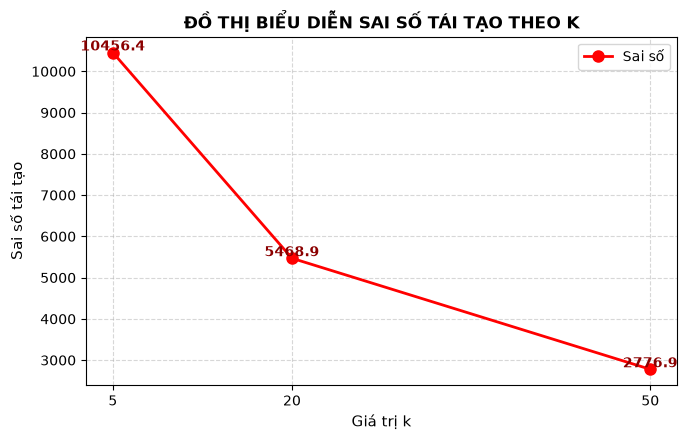

In [12]:
H, W = img_raw.shape
original_elements = H * W 

k_list = [5, 20, 50]
errors = []
compression_rates = []

for k in k_list:
    img_reconstructed = reconstruct(k)
    error = np.linalg.norm(img_raw - img_reconstructed)
    errors.append(error)
    compressed_elements = k * (H + 1 + W)
    rate = original_elements / compressed_elements
    compression_rates.append(rate)

    print(f"Mức k = {k}:")
    print(f"  -> Sai số tái tạo: {error:.2f}")
    print(f"  -> Tỉ lệ nén: {rate:.2f}x (Tiết kiệm dữ liệu ~ {100/rate:.1f}%)\n")

plt.figure(figsize=(7, 4.5))

plt.plot(k_list, errors, marker='o', color='red', linestyle='-', linewidth=2, markersize=8, label='Sai số')

for k, err in zip(k_list, errors):
    plt.text(k, err + 50, f"{err:.1f}", ha='center', fontsize=10, fontweight='bold', color='darkred')

plt.title("ĐỒ THỊ BIỂU DIỄN SAI SỐ TÁI TẠO THEO K", fontsize=12, fontweight='bold')
plt.xlabel("Giá trị k", fontsize=11)
plt.ylabel("Sai số tái tạo", fontsize=11)
plt.xticks(k_list) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### 2.4 - Nhận xét

### 1. Với $k$ nhỏ tới mức nào thì ảnh vẫn chấp nhận được?

Dựa trên kết quả thực nghiệm trực quan ở Câu 2 và các thông số định lượng ở Câu 3, ta có đánh giá như sau:
* **Với $k = 5$:** Ảnh bị nhòe và mất gần như toàn bộ các chi tiết nhỏ. Ta chỉ nhìn thấy các mảng khối sáng tối đại thể của bức ảnh. Ở mức này, sai số tái tạo rất lớn và ảnh **không thể chấp nhận được** cho các tác vụ thông thường.
* **Với $k = 20$:** Bức ảnh đã bắt đầu khôi phục lại hình dáng vật thể rõ ràng, mắt người hoàn toàn có thể nhận diện được nội dung bức ảnh chụp gì. Tuy nhiên, trên ảnh vẫn còn xuất hiện các vệt sọc nhiễu mờ đặc trưng của thuật toán SVD.
* **Với $k = 50$:** Bức ảnh tái tạo đạt độ sắc nét rất cao, các chi tiết nhỏ được khôi phục gần như hoàn chỉnh. Nếu nhìn bằng mắt thường, ảnh $k = 50$ hầu như không có sự khác biệt đáng kể so với ảnh gốc ban đầu, mặc dù đồ thị cho thấy ta đã bỏ đi phần lớn các giá trị kỳ dị nhỏ phía sau.

---

### 2. Liên hệ với giảm chiều dữ liệu và nén dữ liệu trong AI (Ngành ML & IoT)

* **Bản chất nén dữ liệu:** Một bức ảnh thô kích thước $384 \times 384$ chứa rất nhiều vùng pixel là thông tin dư thừa. Phân rã SVD giúp lọc bỏ sự dư thừa đó bằng cách tập trung mật độ năng lượng vào các giá trị kỳ dị đầu tiên. Ví dụ ở $k = 50$, hệ thống chỉ cần lưu một lượng dữ liệu nhỏ hơn ảnh gốc nhiều lần nhưng vẫn giữ được bộ khung thông tin cốt lõi.
* **Mối liên hệ với giảm chiều dữ liệu trong AI:** * Phân rã toán học SVD chính là nền tảng trực tiếp của thuật toán **PCA**.
  * Trong AI, dữ liệu đầu vào thường có số chiều rất lớn (chẳng hạn vector phẳng của ảnh). Việc giảm chiều từ không gian pixel thô khổng lồ xuống một không gian vector nhỏ hơn giúp mô hình AI loại bỏ được nhiễu, tăng tốc độ tính toán khi huấn luyện và ngăn chặn hiện tượng Overfitting.
  * Ý tưởng này cũng tương tự cách các mô hình Deep Learning hiện đại (như Autoencoders hoặc CNN) cố gắng nén bức ảnh qua các tầng mạng để trích xuất ra một Feature Embedding đại diện cho nội dung ảnh thay vì xử lý dữ liệu thô.

### 2.5 - Bonus

--- KẾT QUẢ PHÂN TÍCH NĂNG LƯỢNG ---
Để giữ lại ít nhất 90% thông tin của bức ảnh:
-> Chọn giá trị k tối ưu = 1
-> Năng lượng tích lũy thực tế đạt: 91.43%



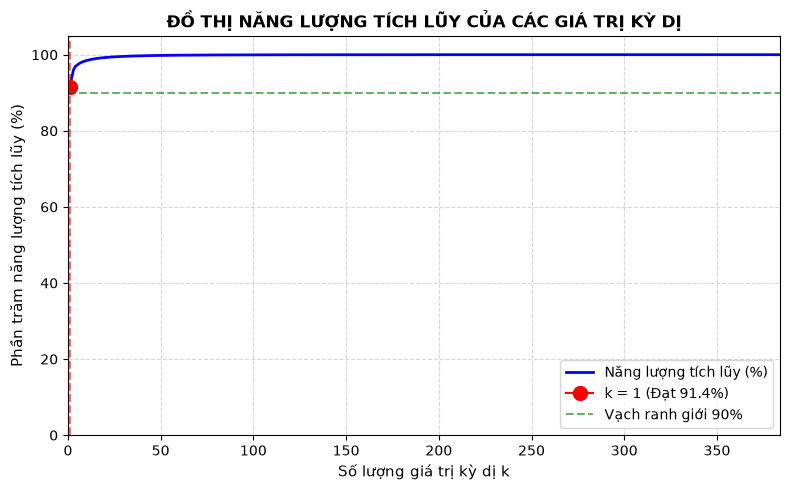

In [14]:
values_squared = S ** 2
cumulative_energy = np.cumsum(values_squared)

total_energy = np.sum(values_squared)
energy_ratio = (cumulative_energy / total_energy) * 100

k_90 = np.where(energy_ratio >= 90)[0][0] + 1
energy_at_k90 = energy_ratio[k_90 - 1]

print("--- KẾT QUẢ PHÂN TÍCH NĂNG LƯỢNG ---")
print(f"Để giữ lại ít nhất 90% thông tin của bức ảnh:")
print(f"-> Chọn giá trị k tối ưu = {k_90}")
print(f"-> Năng lượng tích lũy thực tế đạt: {energy_at_k90:.2f}%\n")

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(S) + 1), energy_ratio, color='blue', linewidth=2, label='Năng lượng tích lũy (%)')
plt.plot(k_90, energy_at_k90, marker='o', markersize=10, color='red', label=f'k = {k_90} (Đạt {energy_at_k90:.1f}%)')

plt.axvline(x=k_90, color='red', linestyle='--', alpha=0.6)
plt.axhline(y=90, color='green', linestyle='--', alpha=0.6, label='Vạch ranh giới 90%')

plt.title("ĐỒ THỊ NĂNG LƯỢNG TÍCH LŨY CỦA CÁC GIÁ TRỊ KỲ DỊ", fontsize=12, fontweight='bold')
plt.xlabel("Số lượng giá trị kỳ dị k", fontsize=11)
plt.ylabel("Phần trăm năng lượng tích lũy (%)", fontsize=11)
plt.xlim(0, len(S))
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()